# Imports

In [1]:
import torch
import numpy as np
import pandas as pd
from imoltance import Imoltance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import random

# Make Dataset

In [2]:
SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

In [ ]:
# imlt = Imoltance('bdpg.csv', 'smiles', ['mpC'], SEED)
# imlt.run()

FileNotFoundError: [Errno 2] No such file or directory: 'bdpg.csv'

# Import and Preprocess Data

In [4]:
train_data_df = pd.read_csv('ochem/imoltance_dump/train_features.csv')
test_data_df = pd.read_csv('ochem/imoltance_dump/test_features.csv')

In [6]:
X_train = train_data_df[[
                        'M1_alpha_ve', 'M1_beta_ve', 'M2_ve', 'R_ve', 'ABC_ve', 'GA_ve',
                        'H_ve', 'X_ve', 'HM1_ve', 'HM2_ve', 'F_ve', 'F1_ve',
                        'ReZG3_ve', 'AG_ve', 'ISI_ve', 'T_ve', 'ID_ve', 'ZD_ve',
                        'mM1_ve', 'T_ev', 'M_ev', 'F_ev', 'mM_ev', 'ID_ev',
                        'R_ev', 'RR_ev'
                    ]]
Y_train = train_data_df['mp']


X_test = test_data_df[[
                        'M1_alpha_ve', 'M1_beta_ve', 'M2_ve', 'R_ve', 'ABC_ve', 'GA_ve',
                        'H_ve', 'X_ve', 'HM1_ve', 'HM2_ve', 'F_ve', 'F1_ve',
                        'ReZG3_ve', 'AG_ve', 'ISI_ve', 'T_ve', 'ID_ve', 'ZD_ve',
                        'mM1_ve', 'T_ev', 'M_ev', 'F_ev', 'mM_ev', 'ID_ev',
                        'R_ev', 'RR_ev'
                    ]]
Y_test = test_data_df['mp']

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

# Training

In [7]:
model = RandomForestRegressor(
    n_estimators=500,
    max_features=0.33,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1,
)

In [8]:
model.fit(X_train, Y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.33
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


# Testing

In [9]:
predictions = model.predict(X_test)

print("R²:", r2_score(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))

R²: 0.2879421474815411
MSE: 2481.2270353545327


Total nodes: 97263550
Average nodes/tree: 194527.1


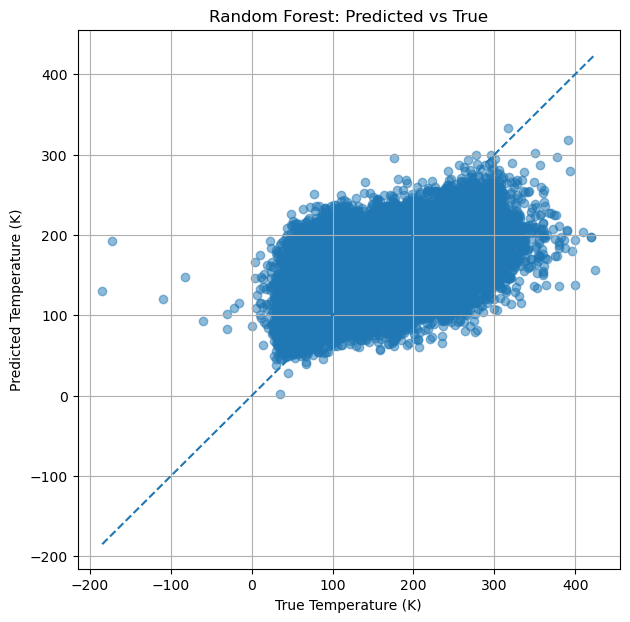

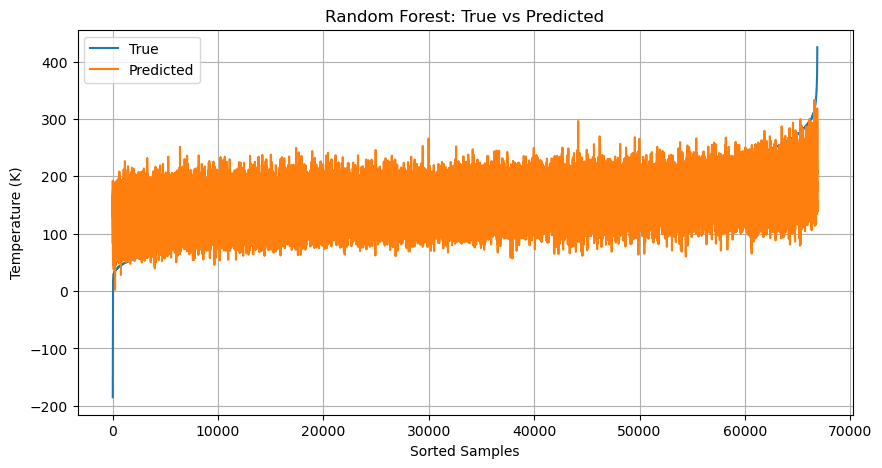

In [10]:
num_nodes = sum(tree.tree_.node_count for tree in model.estimators_)

print("Total nodes:", num_nodes)
print("Average nodes/tree:", num_nodes / len(model.estimators_))

# Flatten just in case
predictions = np.array(predictions).flatten()
Y_test = np.array(Y_test).flatten()

# Scatter plot
plt.figure(figsize=(7, 7))

plt.scatter(Y_test, predictions, alpha=0.5)

mn = min(Y_test.min(), predictions.min())
mx = max(Y_test.max(), predictions.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.xlabel("True Temperature (K)")
plt.ylabel("Predicted Temperature (K)")
plt.title("Random Forest: Predicted vs True")
plt.grid(True)

plt.savefig('prediction-plot1.png', dpi=300)
plt.show()


# Sorted curves
order = np.argsort(Y_test)

plt.figure(figsize=(10, 5))

plt.plot(Y_test[order], label="True")
plt.plot(predictions[order], label="Predicted")

plt.xlabel("Sorted Samples")
plt.ylabel("Temperature (K)")
plt.title("Random Forest: True vs Predicted")
plt.legend()
plt.grid(True)

plt.savefig('prediction-plot2.png', dpi=300)
plt.show()